In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from PIL import Image
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
import sys
print(sys.executable)

d:\Study\venv\Scripts\python.exe


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
model = models.mobilenet_v3_small(pretrained=False)
model.classifier[3] = nn.Linear(1024, 2)

model.load_state_dict(
    torch.load(
        r"D:\Study\ID_Checking\Models\id_check_v1.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

d:\Study\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Study\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\amr samy\AppData\Local\Temp\ipykernel_22644\655261925.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This li

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [4]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
test_dataset = ImageFolder(
    root=r"D:\Study\ID_Checking\Data\processed\test",
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

class_names = test_dataset.classes
print(class_names)  

['ID', 'NOTID']


In [6]:
criterion = nn.CrossEntropyLoss()

In [7]:
model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

test_loss /= test_total
test_acc = test_correct / test_total

print("Test Loss:", round(test_loss, 4))
print("Test Acc :", round(test_acc, 4))

Test Loss: 0.0002
Test Acc : 1.0


In [8]:
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import torch

def predict_and_show(image_path):
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((224, 224))

    img_tensor = eval_transform(img_resized)
    img_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)

    label = "ID" if pred.item() == 0 else "NOT_ID"
    confidence = conf.item()

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"Prediction: {label}\nConfidence: {confidence:.4f}",
        fontsize=12
    )

    plt.show()

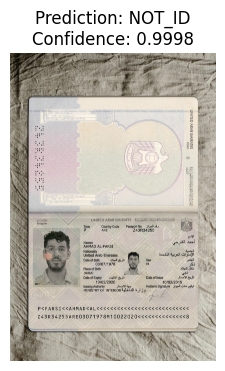

In [10]:
image_path = r"D:\Study\ID_Checking\Data\raw\0_NotID\1.png"
predict_and_show(image_path)

-----------------------------------------------------------------------------------------------------------------

test from scratch model 

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class IDClassifierScratch(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [12]:
model_scratch = IDClassifierScratch().to(device)

model_scratch.load_state_dict(
    torch.load(
        r"D:\Study\ID_Checking\Models\id_scratch_best.pth",
        map_location=device
    )
)

model_scratch.eval()

C:\Users\amr samy\AppData\Local\Temp\ipykernel_22644\541951495.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


IDClassifierScratch(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2,

In [13]:
criterion = nn.CrossEntropyLoss()

test_loss_scratch = 0.0
test_correct_scratch = 0
test_total_scratch = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_scratch(images)
        loss = criterion(outputs, labels)

        test_loss_scratch += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        test_correct_scratch += (preds == labels).sum().item()
        test_total_scratch += labels.size(0)

test_loss_scratch /= test_total_scratch
test_acc_scratch = test_correct_scratch / test_total_scratch

print("Scratch Test Loss:", round(test_loss_scratch, 4))
print("Scratch Test Acc :", round(test_acc_scratch, 4))

Scratch Test Loss: 0.0787
Scratch Test Acc : 0.9805


In [14]:
def predict_and_show_scratch(image_path):
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((224, 224))

    img_tensor = eval_transform(img_resized)
    img_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model_scratch(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)

    label = "ID" if pred.item() == 0 else "NOT_ID"
    confidence = conf.item()

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"[SCRATCH]\nPrediction: {label}\nConfidence: {confidence:.4f}",
        fontsize=12
    )

    plt.show()

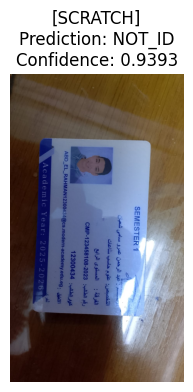

In [21]:
image_path = r"D:\Study\ID_Checking\Data\Experiments\WhatsApp Image 2026-02-15 at 10.58.35 AM.jpeg"
predict_and_show_scratch(image_path)